<a href="https://colab.research.google.com/github/Juliana-Amorim/science-des-donn-es--ducation/blob/main/carte_perceptuelle_analyses_de_correspondance_multiple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving lycees_ips_bac_final.xlsx to lycees_ips_bac_final.xlsx


In [2]:
from google.colab import files
uploaded = files.upload()

Saving regions_academiques.xlsx to regions_academiques.xlsx


In [3]:
import pandas as pd
ips_bac = pd.read_excel('lycees_ips_bac_final.xlsx')

In [4]:
import pandas as pd
regions = pd.read_excel('regions_academiques.xlsx')

In [5]:
MCA_bac_IPS_region = pd.merge(ips_bac, regions, on='UAI', how='inner')
print(MCA_bac_IPS_region)

     Rentrée scolaire_x  Académie_x       UAI  \
0             2023-2024    GRENOBLE  0382895R   
1             2023-2024  NANCY-METZ  0573320Z   
2             2023-2024       LILLE  0595867G   
3             2023-2024       LILLE  0597005U   
4             2023-2024       LILLE  0623902E   
...                 ...         ...       ...   
1538          2023-2024       DIJON  0890003V   
1539          2023-2024     CRETEIL  0932667U   
1540          2023-2024  GUADELOUPE  9710884J   
1541          2023-2024  MARTINIQUE  9720692V   
1542          2023-2024     MAYOTTE  9760127J   

                               Nom de l'établissement_x Secteur_x  \
0                           LYCEE POLYVALENT PH DELORME    public   
1     LYCEE POLYVALENT RAYMOND MONDON LYCEE DES METI...    public   
2     LYCEE GENERAL ET TECHNOLOGIQUE INTERNATIONAL M...    public   
3                        LYCEE POLYVALENT DU VAL DE LYS    public   
4                 LYCEE POLYVALENT MARGUERITE YOURCENAR    public 

In [6]:
MCA_bac_IPS_region = MCA_bac_IPS_region.drop(columns=['Rentrée scolaire_x', 'Académie_x', 'Secteur_x', 'Type de lycée_x', 'Rentrée scolaire_y', "Nom de l'établissement_y", 'Secteur','Type de lycée_y', 'IPS voie GT_y', "Taux d'accès 2nde-bac_y"])


In [7]:
MCA_bac_IPS_region = MCA_bac_IPS_region.rename(columns={'Nom de l\'établissement_x': 'Nom de l\'établissement', 'IPS voie GT_x': 'IPS voie GT', "Taux d'accès 2nde-bac_x": "Taux d'accès 2nde-bac"})

In [8]:
MCA_bac_IPS_region = MCA_bac_IPS_region.drop(columns=['UAI',"Nom de l'établissement", 'Académie'])

In [9]:
print(MCA_bac_IPS_region)

     IPS voie GT Taux d'accès 2nde-bac                   Region
0      IPS.moyen            bac.medium     Auvergne-Rhone-Alpes
1      IPS.moyen              bac.fort                Grand-Est
2      IPS.moyen            bac.faible          Hauts-de-France
3        IPS.bas            bac.medium          Hauts-de-France
4        IPS.bas            bac.faible          Hauts-de-France
...          ...                   ...                      ...
1538   IPS.élevé              bac.fort  Bourgogne-Franche-Comté
1539     IPS.bas              bac.fort            Ile-de-France
1540     IPS.bas              bac.fort                 Caraibes
1541     IPS.bas              bac.fort                 Caraibes
1542     IPS.bas            bac.faible                  Mayotte

[1543 rows x 3 columns]


In [10]:
MCA_bac_IPS_region.to_excel('MCA_bac_IPS_region.xlsx', index=False)

In [11]:
!pip install pandas
!pip install numpy
!pip install scipy
!pip install plotly
!pip install seaborn
!pip install matplotlib
!pip install statsmodels
!pip install prince

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 15.1 MB/s eta 0:00:00


In [12]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
import prince
import plotly.graph_objects as go

In [13]:
print(MCA_bac_IPS_region['IPS voie GT'].value_counts())
print(MCA_bac_IPS_region["Taux d'accès 2nde-bac"].value_counts())
print(MCA_bac_IPS_region["Region"].value_counts())

IPS voie GT
IPS.moyen    515
IPS.bas      514
IPS.élevé    514
Name: count, dtype: int64
Taux d'accès 2nde-bac
bac.medium    565
bac.faible    547
bac.fort      431
Name: count, dtype: int64
Region
Ile-de-France                 308
Auvergne-Rhone-Alpes          175
Grand-Est                     140
Nouvelle-Aquitaine            135
Occitane                      130
Hauts-de-France               129
Provence-Alpes-Côte d'Azur    102
Normandie                      82
Bourgogne-Franche-Comté        70
Pays de la Loire               67
Bretagne                       62
Centre-Val-de-Loire            52
Caraibes                       42
La Reunion                     30
Mayotte                        10
Corse                           9
Name: count, dtype: int64


In [14]:
table_MCA_1 = pd.crosstab(MCA_bac_IPS_region['IPS voie GT'], MCA_bac_IPS_region['Region'])
table_MCA_2 = pd.crosstab(MCA_bac_IPS_region["Taux d'accès 2nde-bac"], MCA_bac_IPS_region['Region'])
table_MCA_3 = pd.crosstab(MCA_bac_IPS_region['IPS voie GT'], MCA_bac_IPS_region["Taux d'accès 2nde-bac"])

In [15]:
print(table_MCA_1)

Region       Auvergne-Rhone-Alpes  Bourgogne-Franche-Comté  Bretagne  \
IPS voie GT                                                            
IPS.bas                        39                       20         4   
IPS.moyen                      63                       32        22   
IPS.élevé                      73                       18        36   

Region       Caraibes  Centre-Val-de-Loire  Corse  Grand-Est  Hauts-de-France  \
IPS voie GT                                                                     
IPS.bas            31                   12      5         59               80   
IPS.moyen           7                   27      3         52               28   
IPS.élevé           4                   13      1         29               21   

Region       Ile-de-France  La Reunion  Mayotte  Normandie  \
IPS voie GT                                                  
IPS.bas                112          24       10         31   
IPS.moyen               57           6        0

In [16]:
print(table_MCA_2)

Region                 Auvergne-Rhone-Alpes  Bourgogne-Franche-Comté  \
Taux d'accès 2nde-bac                                                  
bac.faible                               60                       12   
bac.fort                                 50                       21   
bac.medium                               65                       37   

Region                 Bretagne  Caraibes  Centre-Val-de-Loire  Corse  \
Taux d'accès 2nde-bac                                                   
bac.faible                   25        17                   18      2   
bac.fort                     18        17                    9      3   
bac.medium                   19         8                   25      4   

Region                 Grand-Est  Hauts-de-France  Ile-de-France  La Reunion  \
Taux d'accès 2nde-bac                                                          
bac.faible                    43               65             90          17   
bac.fort                      42 

In [17]:
print(table_MCA_3)

Taux d'accès 2nde-bac  bac.faible  bac.fort  bac.medium
IPS voie GT                                            
IPS.bas                       286        65         163
IPS.moyen                     173       115         227
IPS.élevé                      88       251         175


In [18]:
tab_1 = chi2_contingency(table_MCA_1)

print("IPS x Region")
print(f"qui2: {round(tab_1[0], 2)}")
print(f"p-value: {round(tab_1[1], 4)}")
print(f"degrees_free: {tab_1[2]}")

IPS x Region
qui2: 280.68
p-value: 0.0
degrees_free: 30


In [19]:
tab_2 = chi2_contingency(table_MCA_2)

print("Taux d'accès 2nde-bac x Region")
print(f"qui2 : {round(tab_2[0], 2)}")
print(f"p-value: {round(tab_2[1], 4)}")
print(f"degrees_free: {tab_2[2]}")

Taux d'accès 2nde-bac x Region
qui2 : 116.09
p-value: 0.0
degrees_free: 30


In [20]:
tab_3 = chi2_contingency(table_MCA_3)

print("IPS x Taux d'accès 2nde-bac")
print(f"qui2: {round(tab_3[0], 2)}")
print(f"p-value: {round(tab_3[1], 4)}")
print(f"degrees_free: {tab_3[2]}")

IPS x Taux d'accès 2nde-bac
qui2: 249.63
p-value: 0.0
degrees_free: 4


In [21]:
mca = prince.MCA(n_components=2).fit(MCA_bac_IPS_region)

In [22]:
mca.J_

22

In [23]:
mca.K_

3

In [24]:
binary = pd.get_dummies(MCA_bac_IPS_region, columns=MCA_bac_IPS_region.columns, dtype=int)
print(binary)

      IPS voie GT_IPS.bas  IPS voie GT_IPS.moyen  IPS voie GT_IPS.élevé  \
0                       0                      1                      0   
1                       0                      1                      0   
2                       0                      1                      0   
3                       1                      0                      0   
4                       1                      0                      0   
...                   ...                    ...                    ...   
1538                    0                      0                      1   
1539                    1                      0                      0   
1540                    1                      0                      0   
1541                    1                      0                      0   
1542                    1                      0                      0   

      Taux d'accès 2nde-bac_bac.faible  Taux d'accès 2nde-bac_bac.fort  \
0                        

In [25]:
burt = np.matmul(np.transpose(binary), binary)
print(burt)

                                   IPS voie GT_IPS.bas  IPS voie GT_IPS.moyen  \
IPS voie GT_IPS.bas                                514                      0   
IPS voie GT_IPS.moyen                                0                    515   
IPS voie GT_IPS.élevé                                0                      0   
Taux d'accès 2nde-bac_bac.faible                   286                    173   
Taux d'accès 2nde-bac_bac.fort                      65                    115   
Taux d'accès 2nde-bac_bac.medium                   163                    227   
Region_Auvergne-Rhone-Alpes                         39                     63   
Region_Bourgogne-Franche-Comté                      20                     32   
Region_Bretagne                                      4                     22   
Region_Caraibes                                     31                      7   
Region_Centre-Val-de-Loire                          12                     27   
Region_Corse                

In [26]:
burt.to_excel('burt.xlsx', index=False)

In [27]:
eigenvalues = mca.eigenvalues_summary
print(eigenvalues)

          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              0.528         8.34%                      8.34%
1              0.449         7.09%                     15.43%


In [28]:
coord_burt = mca.column_coordinates(MCA_bac_IPS_region)
print(coord_burt)


                                           0         1
IPS voie GT__IPS.bas                1.034212 -0.527951
IPS voie GT__IPS.moyen             -0.049650  0.961546
IPS voie GT__IPS.élevé             -0.984466 -0.435465
Taux d'accès 2nde-bac__bac.faible   0.818301 -0.163189
Taux d'accès 2nde-bac__bac.fort    -0.949115 -0.711282
Taux d'accès 2nde-bac__bac.medium  -0.068216  0.700578
Region__Auvergne-Rhone-Alpes       -0.365861  0.093397
Region__Bourgogne-Franche-Comté    -0.274543  0.834505
Region__Bretagne                   -0.835871 -0.024717
Region__Caraibes                    1.015751 -1.578590
Region__Centre-Val-de-Loire         0.094116  1.231062
Region__Corse                       0.474183 -0.005046
Region__Grand-Est                   0.263426  0.211846
Region__Hauts-de-France             1.253598 -0.294591
Region__Ile-de-France              -0.467046 -1.077746
Region__La Reunion                  1.942382 -0.594358
Region__Mayotte                     2.860943 -1.554294
Region__No

In [29]:
chart = coord_burt.reset_index()
var_chart = pd.Series(chart['index'].str.split('_', expand=True).iloc[:,0])
chart_df_mca = pd.DataFrame({'category': chart['index'],
                             'obs_x': chart[0],
                             'obs_y': chart[1],
                             'variable':  var_chart})

plt.figure(dpi=1800)

<Figure size 11520x8640 with 0 Axes>

<Figure size 11520x8640 with 0 Axes>

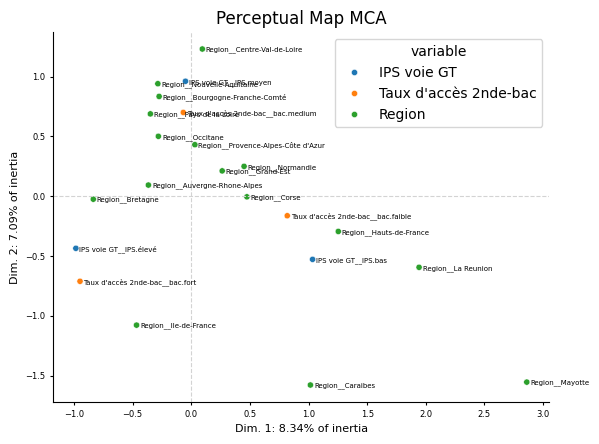

In [30]:
def label_point(x, y, val, ax):
    a = pd.concat({'x': x, 'y': y, 'val': val}, axis=1)
    for i, point in a.iterrows():
        ax.text(point['x']+0.03, point['y']-0.02, point['val'], fontsize=5)

label_point(x = chart_df_mca['obs_x'],
            y = chart_df_mca['obs_y'],
            val = chart_df_mca['category'],
            ax = plt.gca())

sns.scatterplot(data=chart_df_mca, x='obs_x', y='obs_y', hue='variable', s=20)
sns.despine(top=True, right=True, left=False, bottom=False)
plt.axhline(y=0, color='lightgrey', ls='--', linewidth = 0.8)
plt.axvline(x=0, color='lightgrey', ls='--', linewidth = 0.8)
plt.tick_params(size=2, labelsize=6)
plt.title("Perceptual Map MCA", fontsize=12)
plt.xlabel(f"Dim. 1: {eigenvalues.iloc[0,1]} of inertia", fontsize=8)
plt.ylabel(f"Dim. 2: {eigenvalues.iloc[1,1]} of inertia", fontsize=8)
plt.savefig('Perceptual map MCA')